In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 8)

# Load datasets
global_data = pd.read_csv('global_data.csv')
agent_data = pd.read_csv('agent_data.csv')
transaction_data = pd.read_csv('transaction_data.csv')

gpt_global_data = pd.read_csv('gpt_global_data.csv')
gpt_agent_data = pd.read_csv('gpt_agent_data.csv')
gpt_data = pd.read_csv('gpt_data.csv')
gpt_transaction_data = pd.read_csv('gpt_transaction_data.csv')

# Data inspection
print(f"Rule-based Global Data: {global_data.shape}")
print(f"GPT-based Global Data: {gpt_global_data.shape}")
print(f"Rule-based Agent Data: {agent_data.shape}")
print(f"GPT-based Agent Data: {gpt_agent_data.shape}")
print(f"GPT Decision Data: {gpt_data.shape}")
print(f"Rule-based Transactions: {transaction_data.shape}")
print(f"GPT-based Transactions: {gpt_transaction_data.shape}")

# Column info
print("\nGlobal Data Columns:", global_data.columns.tolist())
print("\nAgent Data Columns:", agent_data.columns.tolist())

# Missing value check
print("\nMissing values in Global Data:\n", global_data.isnull().sum())
print("\nTotal missing values in Agent Data:", agent_data.isnull().sum().sum())


Rule-based Global Data: (50, 19)
GPT-based Global Data: (50, 19)
Rule-based Agent Data: (500, 23)
GPT-based Agent Data: (500, 23)
GPT Decision Data: (501, 9)
Rule-based Transactions: (1, 13)
GPT-based Transactions: (0, 13)

Global Data Columns: ['simulation_mode', 'ticks', 'total_new_resources', 'total_recycled_resources', 'total_waste', 'global_pollution_level', 'market_price_waste', 'market_price_resource', 'total_transactions', 'average_transaction_price', 'recycling_efficiency', 'waste_reduction_rate', 'network_density', 'average_node_degree', 'centrality_index', 'api_requests_made', 'total_agent_count', 'recycler_count', 'wasteful_count']

Agent Data Columns: ['simulation_mode', 'ticks', 'who', 'breed', 'energy', 'wealth', 'operational_capacity', 'operational_cost', 'production_rate', 'environmental_concern', 'economic_priority', 'innovation_level', 'cooperation_tendency', 'byproduct_utilization', 'capacity_utilization', 'region_type', 'resource_type', 'resource_quality', 'polluti


Decision Percentage (%):
decision_made
seek_trade           56.89
process_resource     21.16
innovate             11.58
expand_production    10.18
decision_made         0.20
Name: count, dtype: float64


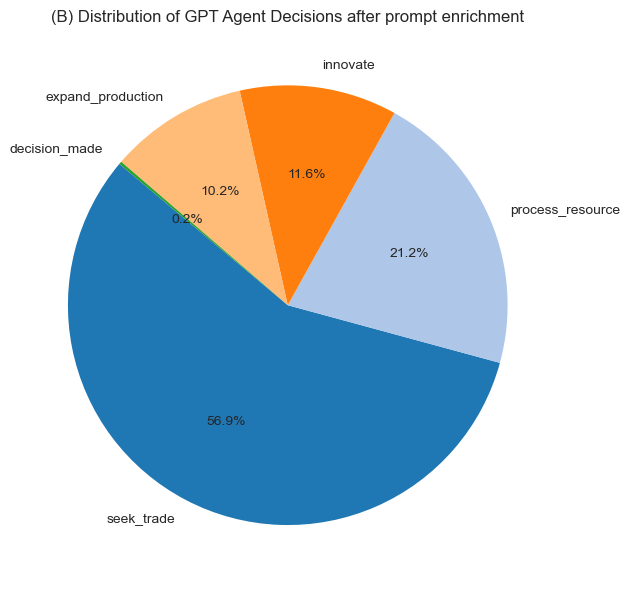

In [4]:
# Analyze GPT decisions
gpt_decisions = gpt_data['decision_made'].value_counts()

# Calculate percentage
decision_percentage = (gpt_decisions / gpt_decisions.sum()) * 100

# Print percentage table
print("\nDecision Percentage (%):")
print(decision_percentage.round(2))

# Plot pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    gpt_decisions, 
    labels=gpt_decisions.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.tab20.colors
)
plt.title('(B) Distribution of GPT Agent Decisions after prompt enrichment')
plt.tight_layout()
plt.show()


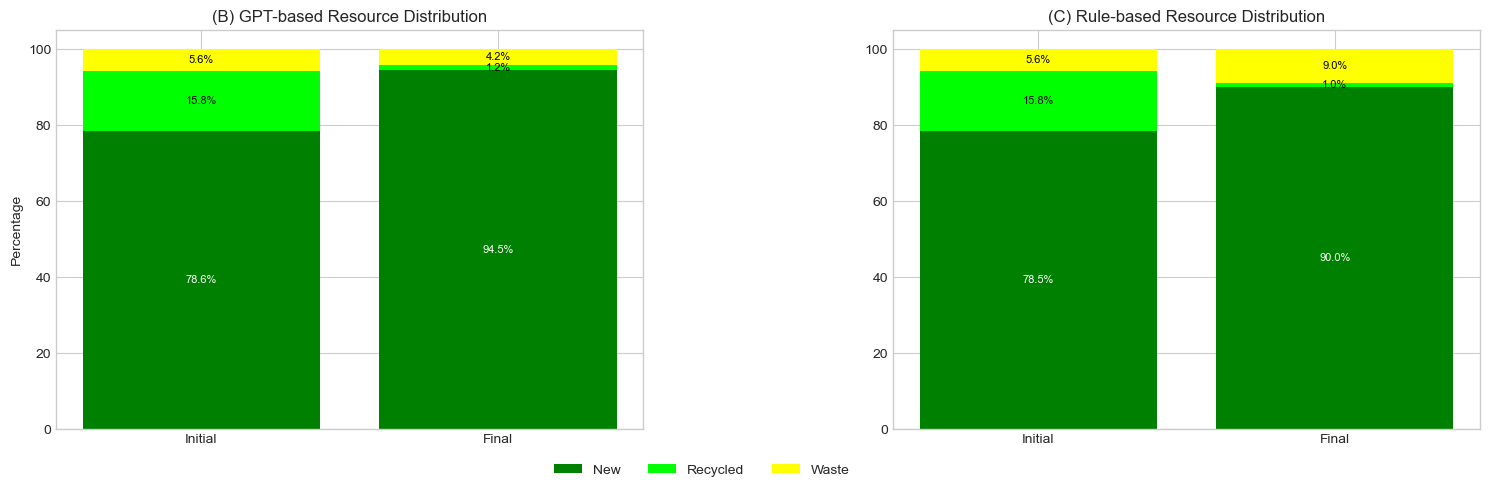

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
rule_global = pd.read_csv('global_data.csv')
gpt_global = pd.read_csv('gpt_global_data.csv')

# Get initial and final ticks
rule_init = rule_global.iloc[0]
rule_final = rule_global.iloc[-1]
gpt_init = gpt_global.iloc[0]
gpt_final = gpt_global.iloc[-1]

# Extract resource values
def get_resource_percentages(row):
    total = row['total_new_resources'] + row['total_recycled_resources'] + row['total_waste']
    return [
        row['total_new_resources'] / total * 100,
        row['total_recycled_resources'] / total * 100,
        row['total_waste'] / total * 100
    ]

rule_init_pct = get_resource_percentages(rule_init)
rule_final_pct = get_resource_percentages(rule_final)
gpt_init_pct = get_resource_percentages(gpt_init)
gpt_final_pct = get_resource_percentages(gpt_final)

# Prepare data
labels = ['Initial', 'Final']
width = 0.4

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# GPT-based plot
axes[0].bar(labels, [gpt_init_pct[0], gpt_final_pct[0]], color='green', label='New')
axes[0].bar(labels, [gpt_init_pct[1], gpt_final_pct[1]], bottom=[gpt_init_pct[0], gpt_final_pct[0]], color='lime', label='Recycled')
axes[0].bar(labels, [gpt_init_pct[2], gpt_final_pct[2]], bottom=[gpt_init_pct[0] + gpt_init_pct[1], gpt_final_pct[0] + gpt_final_pct[1]], color='yellow', label='Waste')

axes[0].set_title('(B) GPT-based Resource Distribution')
axes[0].set_ylabel('Percentage')
for i, (new, rec, waste) in enumerate(zip([gpt_init_pct[0], gpt_final_pct[0]], [gpt_init_pct[1], gpt_final_pct[1]], [gpt_init_pct[2], gpt_final_pct[2]])):
    axes[0].text(i, new/2, f'{new:.1f}%', ha='center', va='center', color='white', fontsize=8)
    axes[0].text(i, new + rec/2, f'{rec:.1f}%', ha='center', va='center', color='black', fontsize=8)
    axes[0].text(i, new + rec + waste/2, f'{waste:.1f}%', ha='center', va='center', color='black', fontsize=8)

# Rule-based plot
axes[1].bar(labels, [rule_init_pct[0], rule_final_pct[0]], color='green', label='New')
axes[1].bar(labels, [rule_init_pct[1], rule_final_pct[1]], bottom=[rule_init_pct[0], rule_final_pct[0]], color='lime', label='Recycled')
axes[1].bar(labels, [rule_init_pct[2], rule_final_pct[2]], bottom=[rule_init_pct[0] + rule_init_pct[1], rule_final_pct[0] + rule_final_pct[1]], color='yellow', label='Waste')

axes[1].set_title('(C) Rule-based Resource Distribution')
for i, (new, rec, waste) in enumerate(zip([rule_init_pct[0], rule_final_pct[0]], [rule_init_pct[1], rule_final_pct[1]], [rule_init_pct[2], rule_final_pct[2]])):
    axes[1].text(i, new/2, f'{new:.1f}%', ha='center', va='center', color='white', fontsize=8)
    axes[1].text(i, new + rec/2, f'{rec:.1f}%', ha='center', va='center', color='black', fontsize=8)
    axes[1].text(i, new + rec + waste/2, f'{waste:.1f}%', ha='center', va='center', color='black', fontsize=8)

# Legend
axes[0].legend(loc='lower center', bbox_to_anchor=(1.1, -0.15), ncol=3)

plt.tight_layout()
plt.show()


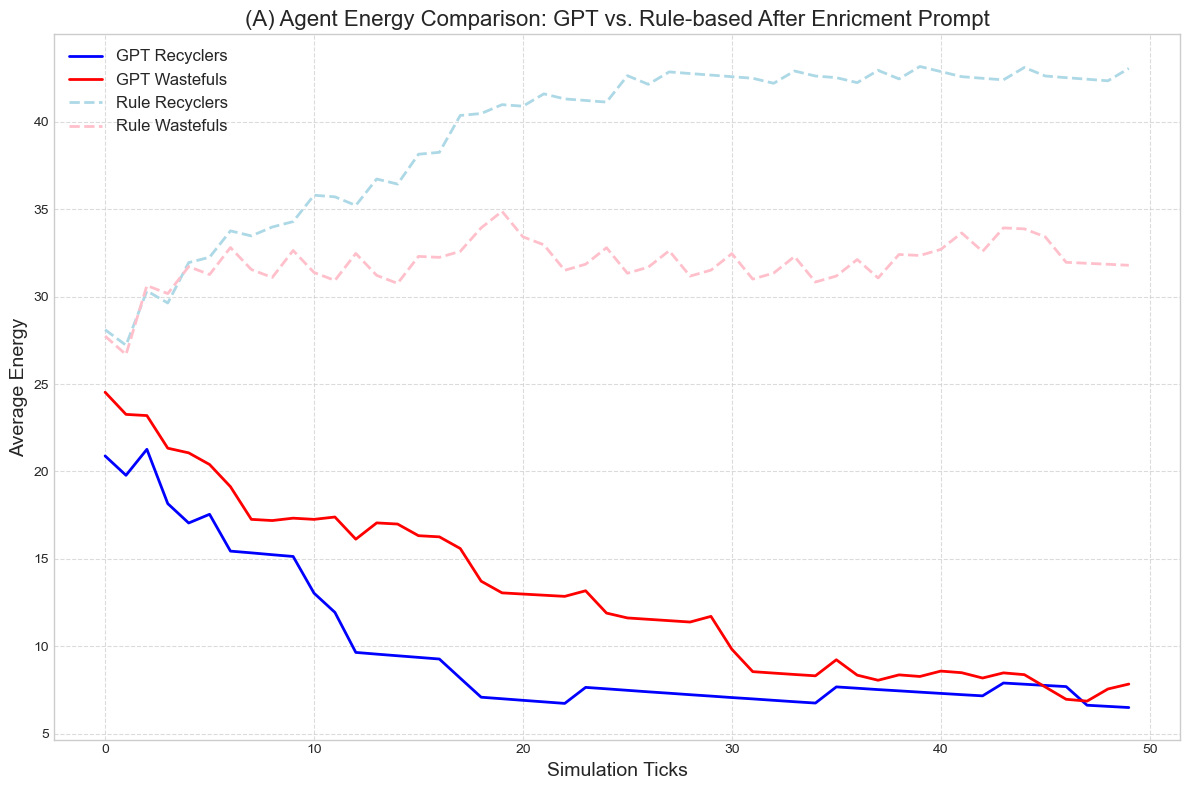

In [8]:
#Load agent data
gpt_agent = pd.read_csv('gpt_agent_data.csv')
rule_agent = pd.read_csv('agent_data.csv')

# Separate by breed
gpt_recyclers = gpt_agent[gpt_agent['breed'] == 'recyclers']
gpt_wastefuls = gpt_agent[gpt_agent['breed'] == 'wastefuls']
rule_recyclers = rule_agent[rule_agent['breed'] == 'recyclers']
rule_wastefuls = rule_agent[rule_agent['breed'] == 'wastefuls']

# Calculate average energy per tick
gpt_recycler_stats = gpt_recyclers.groupby('ticks')['energy'].mean()
gpt_wasteful_stats = gpt_wastefuls.groupby('ticks')['energy'].mean()
rule_recycler_stats = rule_recyclers.groupby('ticks')['energy'].mean()
rule_wasteful_stats = rule_wastefuls.groupby('ticks')['energy'].mean()

# Plot energy comparison
plt.figure(figsize=(12, 8))
plt.plot(gpt_recycler_stats.index, gpt_recycler_stats.values, label='GPT Recyclers', color='blue', linewidth=2)
plt.plot(gpt_wasteful_stats.index, gpt_wasteful_stats.values, label='GPT Wastefuls', color='red', linewidth=2)
plt.plot(rule_recycler_stats.index, rule_recycler_stats.values, label='Rule Recyclers', color='lightblue', linewidth=2, linestyle='--')
plt.plot(rule_wasteful_stats.index, rule_wasteful_stats.values, label='Rule Wastefuls', color='pink', linewidth=2, linestyle='--')

plt.title('(A) Agent Energy Comparison: GPT vs. Rule-based After Enricment Prompt', fontsize=16)
plt.xlabel('Simulation Ticks', fontsize=14)
plt.ylabel('Average Energy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Decision Percentage:
decision_made
seek_trade           56.89
process_resource     21.16
innovate             11.58
expand_production    10.18
decision_made         0.20
Name: count, dtype: float64


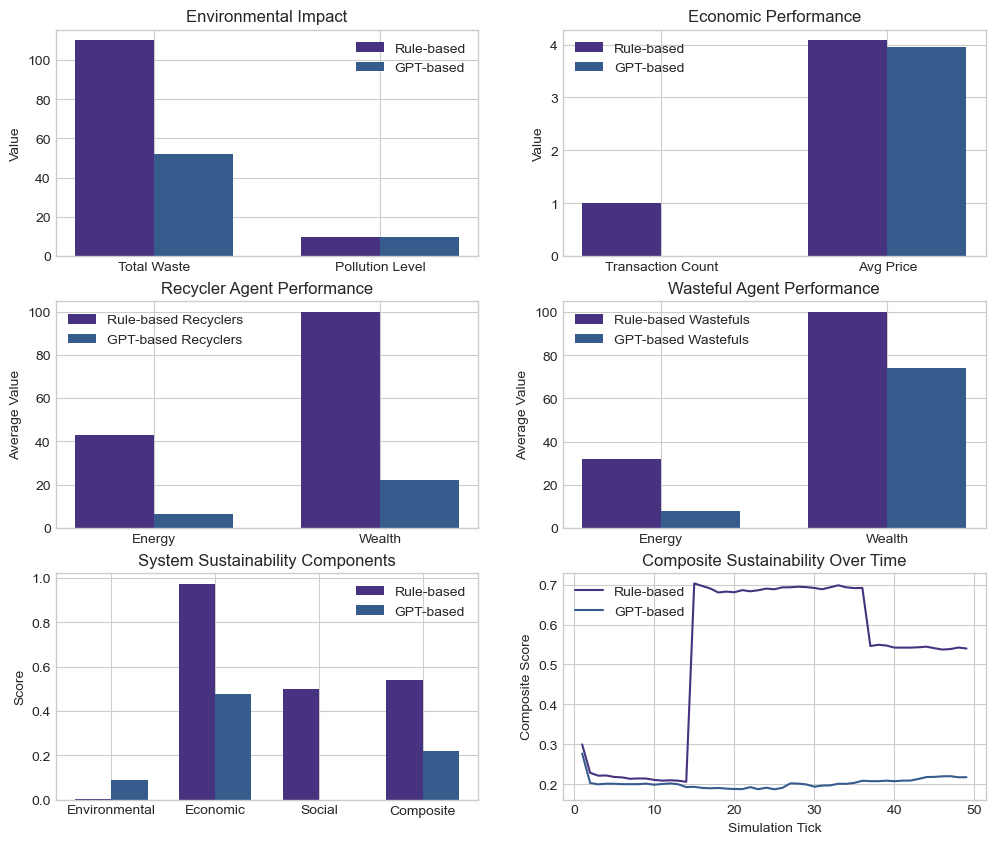

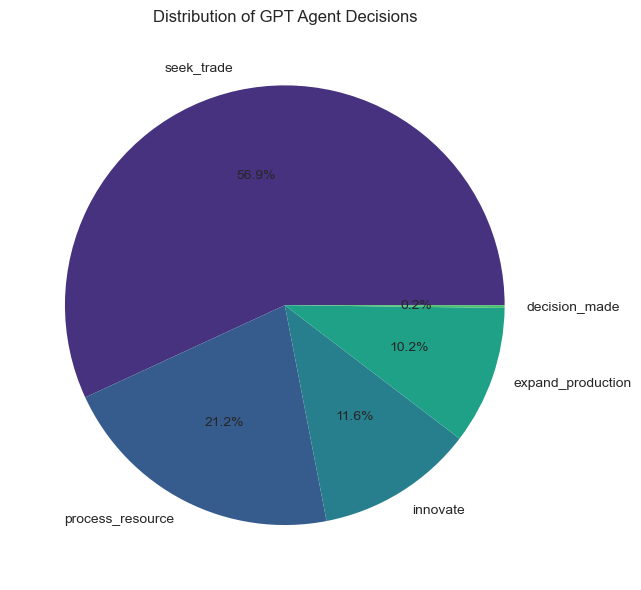

<Figure size 1200x800 with 0 Axes>

In [7]:
# --- 7.1 Impact of GPT-based Decision Making on System Sustainability ---

# Step 1: Make sure sustainability data is calculated
def calculate_env_sustainability(data):
    max_pollution = max(data['global_pollution_level'].max(), 1)
    norm_pollution = 1 - (data['global_pollution_level'] / max_pollution)
    max_waste = max(data['total_waste'].max(), 1)
    norm_waste = 1 - (data['total_waste'] / max_waste)
    max_recycling = max(data['recycling_efficiency'].max(), 1)
    norm_recycling = data['recycling_efficiency'] / max_recycling
    return (norm_pollution + norm_waste + norm_recycling) / 3

def sustainability_index(data):
    env_score = calculate_env_sustainability(data)
    econ_activity = data['total_transactions'] / max(data['total_transactions'].max(), 1)
    price_stability = 1 - (data['market_price_resource'].rolling(5, min_periods=1).std() / data['market_price_resource'].mean())
    econ_score = (econ_activity + price_stability) / 2
    social_score = (data['network_density'] / max(data['network_density'].max(), 0.001) + 
                    data['average_node_degree'] / max(data['average_node_degree'].max(), 0.001)) / 2
    composite = 0.3 * env_score + 0.4 * econ_score + 0.3 * social_score
    return pd.DataFrame({
        'Tick': data['ticks'],
        'Environmental': env_score,
        'Economic': econ_score,
        'Social': social_score,
        'Composite': composite
    })

# Calculate sustainability indices
rule_sustainability = sustainability_index(global_data)
gpt_sustainability = sustainability_index(gpt_global_data)

# Step 2: Determine last common tick
last_tick = min(global_data['ticks'].max(), gpt_global_data['ticks'].max())

# Step 3: Prepare last state data
rule_last = global_data[global_data['ticks'] == last_tick]
gpt_last = gpt_global_data[gpt_global_data['ticks'] == last_tick]

rule_last_agents = agent_data[agent_data['ticks'] == last_tick]
gpt_last_agents = gpt_agent_data[gpt_agent_data['ticks'] == last_tick]

# Step 4: Plot
plt.figure(figsize=(12, 10))
width = 0.35

# --- Environmental Impact ---
plt.subplot(3, 2, 1)
env_metrics = ['total_waste', 'global_pollution_level']
env_labels = ['Total Waste', 'Pollution Level']
rule_env_values = [rule_last[metric].values[0] for metric in env_metrics]
gpt_env_values = [gpt_last[metric].values[0] for metric in env_metrics]

x_env = np.arange(len(env_metrics))

plt.bar(x_env - width/2, rule_env_values, width, label='Rule-based')
plt.bar(x_env + width/2, gpt_env_values, width, label='GPT-based')
plt.xticks(x_env, env_labels)
plt.title('Environmental Impact')
plt.ylabel('Value')
plt.legend()

# --- Economic Performance ---
plt.subplot(3, 2, 2)
econ_metrics = ['total_transactions', 'average_transaction_price']
econ_labels = ['Transaction Count', 'Avg Price']
rule_econ_values = [rule_last[metric].values[0] for metric in econ_metrics]
gpt_econ_values = [gpt_last[metric].values[0] for metric in econ_metrics]

x_econ = np.arange(len(econ_metrics))

plt.bar(x_econ - width/2, rule_econ_values, width, label='Rule-based')
plt.bar(x_econ + width/2, gpt_econ_values, width, label='GPT-based')
plt.xticks(x_econ, econ_labels)
plt.title('Economic Performance')
plt.ylabel('Value')
plt.legend()

# --- Recycler Agent Performance ---
plt.subplot(3, 2, 3)
agent_metrics = ['energy', 'wealth']
agent_labels = ['Energy', 'Wealth']

rule_recyclers = rule_last_agents[rule_last_agents['breed'] == 'recyclers']
gpt_recyclers = gpt_last_agents[gpt_last_agents['breed'] == 'recyclers']

rule_recyclers_values = [rule_recyclers[metric].mean() for metric in agent_metrics]
gpt_recyclers_values = [gpt_recyclers[metric].mean() for metric in agent_metrics]

x_agent = np.arange(len(agent_metrics))

plt.bar(x_agent - width/2, rule_recyclers_values, width, label='Rule-based Recyclers')
plt.bar(x_agent + width/2, gpt_recyclers_values, width, label='GPT-based Recyclers')
plt.xticks(x_agent, agent_labels)
plt.title('Recycler Agent Performance')
plt.ylabel('Average Value')
plt.legend()

# --- Wasteful Agent Performance ---
plt.subplot(3, 2, 4)
rule_wastefuls = rule_last_agents[rule_last_agents['breed'] == 'wastefuls']
gpt_wastefuls = gpt_last_agents[gpt_last_agents['breed'] == 'wastefuls']

rule_wastefuls_values = [rule_wastefuls[metric].mean() for metric in agent_metrics]
gpt_wastefuls_values = [gpt_wastefuls[metric].mean() for metric in agent_metrics]

plt.bar(x_agent - width/2, rule_wastefuls_values, width, label='Rule-based Wastefuls')
plt.bar(x_agent + width/2, gpt_wastefuls_values, width, label='GPT-based Wastefuls')
plt.xticks(x_agent, agent_labels)
plt.title('Wasteful Agent Performance')
plt.ylabel('Average Value')
plt.legend()

# --- System Sustainability Components ---
plt.subplot(3, 2, 5)
sustainability_metrics = ['Environmental', 'Economic', 'Social', 'Composite']
rule_sust_values = [rule_sustainability[rule_sustainability['Tick'] == last_tick][metric].values[0] for metric in sustainability_metrics]
gpt_sust_values = [gpt_sustainability[gpt_sustainability['Tick'] == last_tick][metric].values[0] for metric in sustainability_metrics]

x_sust = np.arange(len(sustainability_metrics))

plt.bar(x_sust - width/2, rule_sust_values, width, label='Rule-based')
plt.bar(x_sust + width/2, gpt_sust_values, width, label='GPT-based')
plt.xticks(x_sust, sustainability_metrics)
plt.title('System Sustainability Components')
plt.ylabel('Score')
plt.legend()

# --- Composite Sustainability Over Time ---
plt.subplot(3, 2, 6)
plt.plot(rule_sustainability['Tick'], rule_sustainability['Composite'], label='Rule-based')
plt.plot(gpt_sustainability['Tick'], gpt_sustainability['Composite'], label='GPT-based')
plt.title('Composite Sustainability Over Time')
plt.xlabel('Simulation Tick')
plt.ylabel('Composite Score')
plt.grid(True)
plt.legend()

# Analyze GPT decisions
gpt_decisions = gpt_data['decision_made'].value_counts()
# Calculate percentage
decision_percentage = gpt_decisions / gpt_decisions.sum() * 100
print("\nDecision Percentage:")
print(decision_percentage.round(2))

# Plot decisions
plt.figure(figsize=(10, 6))
plt.pie(gpt_decisions, labels=gpt_decisions.index, autopct='%1.1f%%')
plt.title('Distribution of GPT Agent Decisions')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


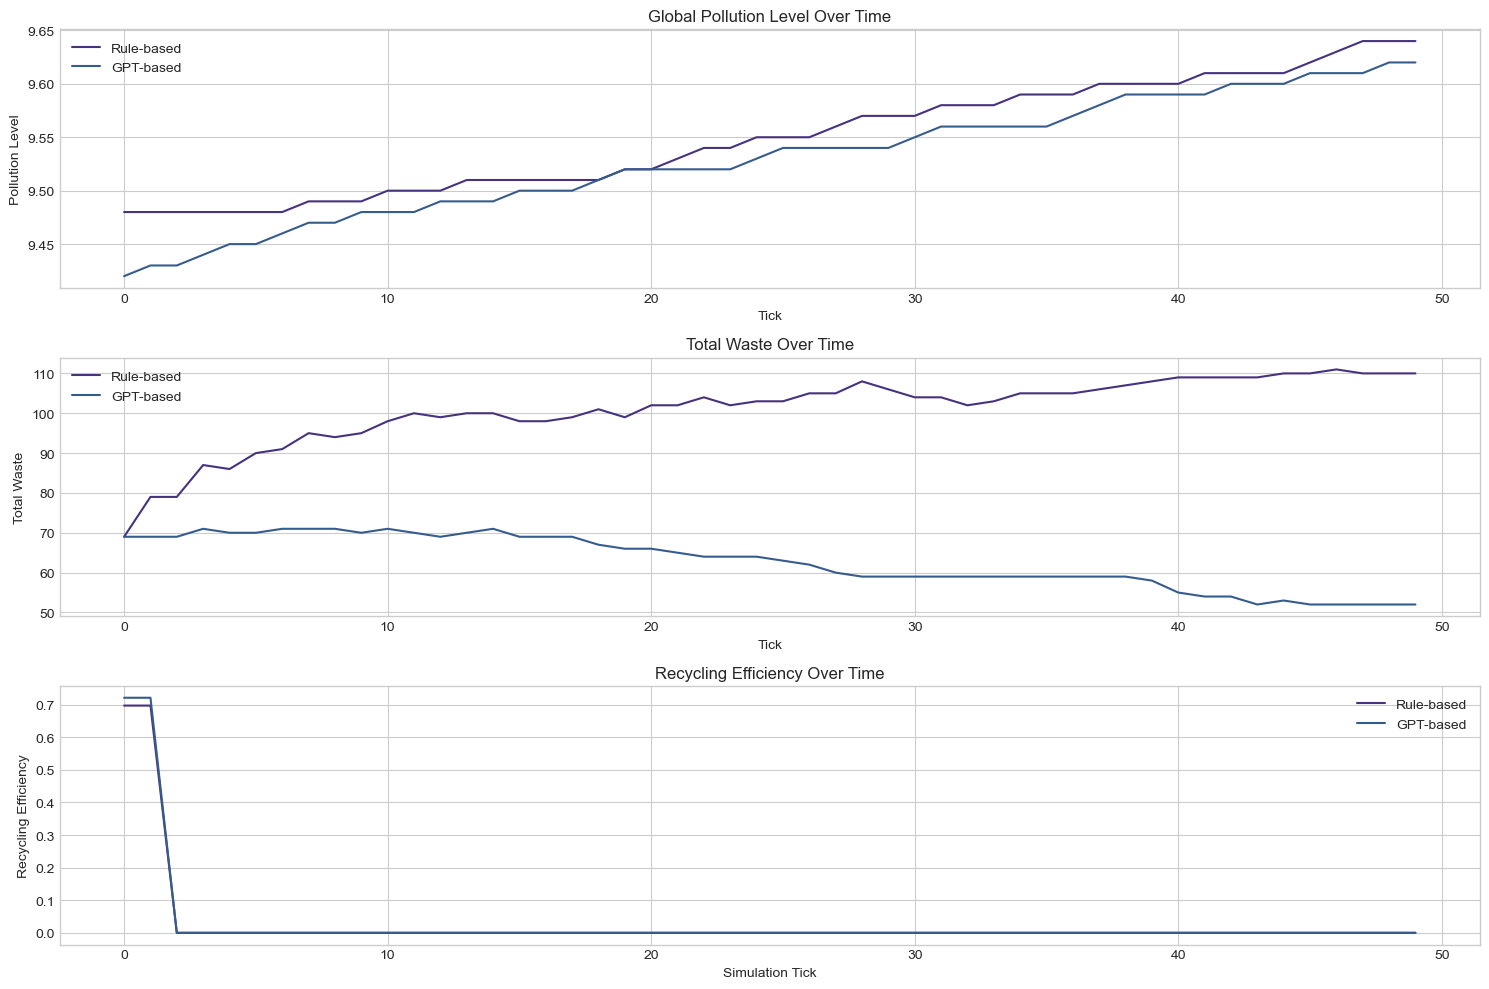

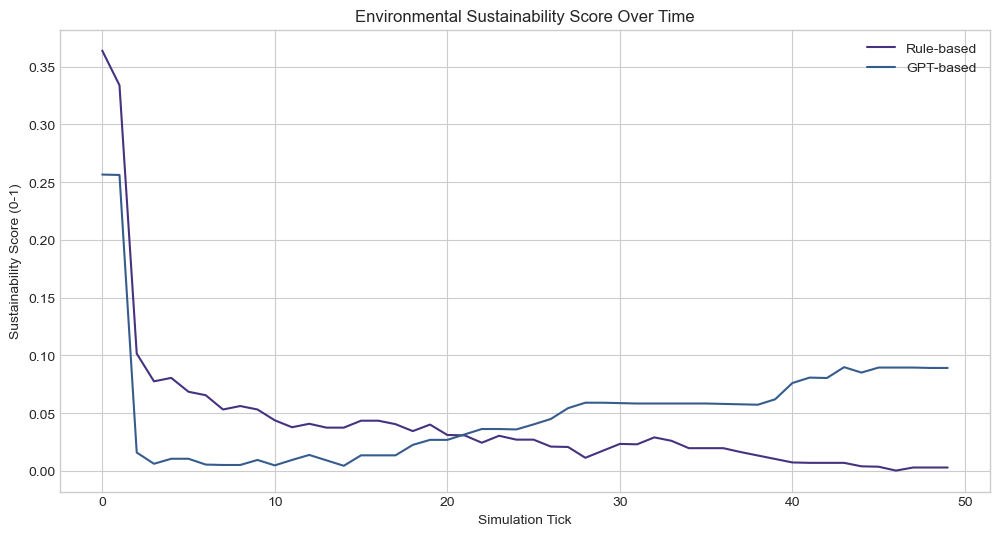

In [6]:
# Create comparison dataframes for environmental metrics
pollution_df = create_comparison_df(global_data, gpt_global_data, 'global_pollution_level')
waste_df = create_comparison_df(global_data, gpt_global_data, 'total_waste')
recycling_df = create_comparison_df(global_data, gpt_global_data, 'recycling_efficiency')

# Plot pollution levels over time
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
sns.lineplot(data=pollution_df, x='Tick', y='Rule-based', label='Rule-based')
sns.lineplot(data=pollution_df, x='Tick', y='GPT-based', label='GPT-based')
plt.title('Global Pollution Level Over Time')
plt.ylabel('Pollution Level')
plt.grid(True)

plt.subplot(3, 1, 2)
sns.lineplot(data=waste_df, x='Tick', y='Rule-based', label='Rule-based')
sns.lineplot(data=waste_df, x='Tick', y='GPT-based', label='GPT-based')
plt.title('Total Waste Over Time')
plt.ylabel('Total Waste')
plt.grid(True)

plt.subplot(3, 1, 3)
sns.lineplot(data=recycling_df, x='Tick', y='Rule-based', label='Rule-based')
sns.lineplot(data=recycling_df, x='Tick', y='GPT-based', label='GPT-based')
plt.title('Recycling Efficiency Over Time')
plt.ylabel('Recycling Efficiency')
plt.xlabel('Simulation Tick')
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate environmental sustainability score
def calculate_env_sustainability(data):
    """Calculate a composite environmental sustainability score"""
    # Normalize pollution (lower is better)
    max_pollution = max(data['global_pollution_level'].max(), 1)
    norm_pollution = 1 - (data['global_pollution_level'] / max_pollution)
    
    # Normalize waste (lower is better)
    max_waste = max(data['total_waste'].max(), 1)
    norm_waste = 1 - (data['total_waste'] / max_waste)
    
    # Normalize recycling (higher is better)
    max_recycling = max(data['recycling_efficiency'].max(), 1)
    norm_recycling = data['recycling_efficiency'] / max_recycling
    
    # Composite score (equal weights)
    return (norm_pollution + norm_waste + norm_recycling) / 3

rule_env_score = calculate_env_sustainability(global_data)
gpt_env_score = calculate_env_sustainability(gpt_global_data)

env_score_df = pd.DataFrame({
    'Tick': global_data['ticks'],
    'Rule-based': rule_env_score,
    'GPT-based': gpt_env_score
})

plt.figure(figsize=(12, 6))
sns.lineplot(data=env_score_df, x='Tick', y='Rule-based', label='Rule-based')
sns.lineplot(data=env_score_df, x='Tick', y='GPT-based', label='GPT-based')
plt.title('Environmental Sustainability Score Over Time')
plt.ylabel('Sustainability Score (0-1)')
plt.xlabel('Simulation Tick')
plt.grid(True)
plt.show()

In [2]:
def create_comparison_df(rule_data, gpt_data, metric, tick_range=None):
    """Create a comparison DataFrame for a metric."""
    if tick_range:
        rule_data = rule_data[rule_data['ticks'].isin(tick_range)]
        gpt_data = gpt_data[gpt_data['ticks'].isin(tick_range)]
    return pd.DataFrame({
        'Tick': rule_data['ticks'],
        'Rule-based': rule_data[metric],
        'GPT-based': gpt_data[metric]
    })

def analyze_transactions(data):
    """Analyze transaction patterns."""
    if len(data) == 0:
        return pd.DataFrame()
    transactions_by_tick = data.groupby('ticks').size().reset_index(name='count')
    sender_types = data.groupby('sender_type').size().reset_index(name='count')
    receiver_types = data.groupby('receiver_type').size().reset_index(name='count')
    avg_transfer = data.groupby('ticks')['transfer_amount'].mean().reset_index()
    avg_price = data.groupby('ticks')['transfer_price'].mean().reset_index()
    return {'by_tick': transactions_by_tick, 'sender_types': sender_types, 
            'receiver_types': receiver_types, 'avg_transfer': avg_transfer, 
            'avg_price': avg_price}

def calculate_energy_flow(data):
    """Calculate energy flow through trading."""
    if len(data) == 0:
        return pd.DataFrame()
    flow_matrix = pd.DataFrame(0, index=['recyclers', 'wastefuls'], columns=['recyclers', 'wastefuls'])
    for _, row in data.iterrows():
        sender = row['sender_type']
        receiver = row['receiver_type']
        amount = row['transfer_amount']
        if sender in flow_matrix.index and receiver in flow_matrix.columns:
            flow_matrix.loc[sender, receiver] += amount
    return flow_matrix

def sustainability_index(data):
    """Calculate a composite sustainability index."""
    env_score = calculate_env_sustainability(data)
    econ_activity = data['total_transactions'] / max(data['total_transactions'].max(), 1)
    price_stability = 1 - (data['market_price_resource'].rolling(5, min_periods=1).std() / data['market_price_resource'].mean())
    econ_score = (econ_activity + price_stability) / 2
    social_score = (data['network_density'] / max(data['network_density'].max(), 0.001) +
                    data['average_node_degree'] / max(data['average_node_degree'].max(), 0.001)) / 2
    composite = 0.3 * env_score + 0.4 * econ_score + 0.3 * social_score
    return pd.DataFrame({'Tick': data['ticks'], 'Environmental': env_score, 'Economic': econ_score, 'Social': social_score, 'Composite': composite})

def analyze_cooperation_by_breed(data):
    """Analyze cooperation tendency by agent breed."""
    cooperation_by_breed = data.groupby(['ticks', 'breed'])['cooperation_tendency'].mean().reset_index()
    return cooperation_by_breed.pivot(index='ticks', columns='breed', values='cooperation_tendency')

def analyze_agent_performance(data, metric):
    """Analyze an agent metric over time by breed."""
    by_breed = data.groupby(['ticks', 'breed'])[metric].mean().reset_index()
    return by_breed.pivot(index='ticks', columns='breed', values=metric)

def gini_coefficient(x):
    """Calculate the Gini coefficient."""
    x = np.array(x, dtype=np.float64)
    n = len(x)
    if n <= 1: return 0
    x = np.sort(x)
    cumsum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

def calculate_gini_by_tick(data):
    """Calculate Gini for each simulation tick."""
    gini_values = []
    ticks = sorted(data['ticks'].unique())
    for tick in ticks:
        tick_data = data[data['ticks'] == tick]
        gini = gini_coefficient(tick_data['wealth'].values)
        gini_values.append(gini)
    return pd.DataFrame({'Tick': ticks, 'Gini': gini_values})

def calculate_env_sustainability(data):
    """Composite environmental score: pollution, waste, recycling."""
    max_pollution = max(data['global_pollution_level'].max(), 1)
    norm_pollution = 1 - (data['global_pollution_level'] / max_pollution)
    max_waste = max(data['total_waste'].max(), 1)
    norm_waste = 1 - (data['total_waste'] / max_waste)
    max_recycling = max(data['recycling_efficiency'].max(), 1)
    norm_recycling = data['recycling_efficiency'] / max_recycling
    return (norm_pollution + norm_waste + norm_recycling) / 3

def calculate_econ_health(data):
    """Composite economic health score."""
    max_transactions = max(data['total_transactions'].max(), 1)
    norm_transactions = data['total_transactions'] / max_transactions
    price_stability = 1 - (data['market_price_resource'].rolling(5, min_periods=1).std() / data['market_price_resource'].mean())
    return (norm_transactions + price_stability) / 2
